In [1]:
from pyspark.sql import SparkSession
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml.feature import PCAModel, PCA
import matplotlib.pyplot as plt
import pandas as pd

spark = SparkSession.builder \
    .appName("Ecommerce_KMeans") \
    .getOrCreate()

train_data = spark.read.parquet("hdfs://localhost:9000/user/bigdata/data/ml_train_data.parquet")
test_data = spark.read.parquet("hdfs://localhost:9000/user/bigdata/data/ml_test_data.parquet")

print(f"Tập Train: {train_data.count()} bản ghi")
print(f"Tập Test: {test_data.count()} bản ghi")

Tập Train: 800257 bản ghi
Tập Test: 199743 bản ghi


In [2]:
# Tính Silhouette Score cho k = 2 đến 8
evaluator = ClusteringEvaluator(
    predictionCol="prediction",
    featuresCol="features",
    metricName="silhouette"
)

silhouette_scores = []

for k in range(2, 9):
    kmeans = KMeans(k=k, seed=42, featuresCol="features")
    model = kmeans.fit(train_data)
    predictions = model.transform(train_data)
    score = evaluator.evaluate(predictions)
    silhouette_scores.append((k, score))
    print(f"K = {k} | Silhouette Score = {score:.4f}")

print("\nDanh sách kết quả:")
for k, score in silhouette_scores:
    print(f"  K={k}: {score:.4f}")

K = 2 | Silhouette Score = 0.1588
K = 3 | Silhouette Score = 0.2381
K = 4 | Silhouette Score = 0.3174
K = 5 | Silhouette Score = 0.3966
K = 6 | Silhouette Score = 0.4761
K = 7 | Silhouette Score = 0.4010
K = 8 | Silhouette Score = 0.3560

Danh sách kết quả:
  K=2: 0.1588
  K=3: 0.2381
  K=4: 0.3174
  K=5: 0.3966
  K=6: 0.4761
  K=7: 0.4010
  K=8: 0.3560


K tối ưu: 6 (Silhouette Score = 0.4761)


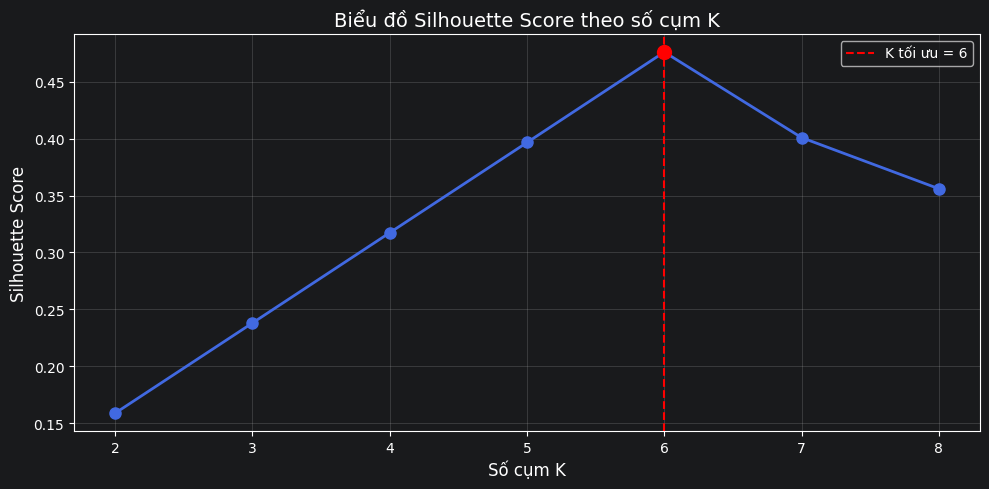

In [3]:
k_values = [x[0] for x in silhouette_scores]
scores = [x[1] for x in silhouette_scores]

# Tìm K tối ưu
k_optimal = k_values[scores.index(max(scores))]
print(f"K tối ưu: {k_optimal} (Silhouette Score = {max(scores):.4f})")

# Vẽ biểu đồ
plt.figure(figsize=(10, 5))
plt.plot(k_values, scores, marker="o", color="royalblue", linewidth=2, markersize=8)
plt.axvline(x=k_optimal, color="red", linestyle="--", label=f"K tối ưu = {k_optimal}")
plt.scatter([k_optimal], [max(scores)], color="red", zorder=5, s=100)
plt.title("Biểu đồ Silhouette Score theo số cụm K", fontsize=14)
plt.xlabel("Số cụm K", fontsize=12)
plt.ylabel("Silhouette Score", fontsize=12)
plt.xticks(k_values)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
# Huấn luyện với K tối ưu
kmeans_final = KMeans(k=k_optimal, seed=42, featuresCol="features")
model_final = kmeans_final.fit(train_data)

# Hiển thị tọa độ tâm cụm
import pandas as pd
import numpy as np

centers = model_final.clusterCenters()

n_features = len(centers[0])
feature_names = [f"feature_{i}" for i in range(n_features)]

centers_df = pd.DataFrame(
    [[round(float(x), 4) for x in center] for center in centers],
    columns=feature_names
)
centers_df.index.name = "Cụm"
centers_df

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13
Cụm,,,,,,,,,,,,,,
0,2.2335,-0.4477,-0.4473,-0.4473,-0.4467,-0.4466,-0.0016,0.0032,-0.0001,-0.0010,0.0027,0.0051,0.0041,-0.0011
1,-0.4477,-0.4477,-0.4473,-0.4473,2.2387,-0.4466,0.0017,0.0034,-0.0025,-0.0007,-0.0056,-0.0006,-0.0017,0.0016
2,-0.4477,-0.4477,2.2357,-0.4473,-0.4467,-0.4466,-0.0021,-0.0022,0.0001,-0.0003,0.0005,0.0003,0.0014,0.0016
3,-0.4477,-0.4477,-0.4473,-0.4473,-0.4467,2.2392,-0.0010,-0.0024,0.0017,-0.0033,-0.0034,-0.0032,-0.0021,-0.0016
4,-0.4477,2.2335,-0.4473,-0.4473,-0.4467,-0.4466,0.0035,-0.0009,-0.0023,0.0033,0.0031,-0.0022,0.0003,-0.0043
5,-0.4477,-0.4477,-0.4473,2.2358,-0.4467,-0.4466,-0.0016,0.0002,0.0015,0.0008,0.0004,0.0039,-0.0004,0.0026


In [5]:
# Dự đoán
predictions = model_final.transform(test_data)

# Xem phân bố số lượng từng cụm
print("Phân bố số lượng bản ghi theo cụm:")
phan_bo = predictions.groupBy("prediction") \
    .count() \
    .orderBy("prediction") \
    .toPandas()
phan_bo

Phân bố số lượng bản ghi theo cụm:


,prediction,count
0,0,33215
1,1,33492
2,2,33385
3,3,33407
4,4,33055
5,5,33189


In [6]:
# Tính Silhouette Score trên tập test
silhouette_final = evaluator.evaluate(predictions)
print(f"Silhouette Score trên tập Test: {silhouette_final:.4f}")

if silhouette_final >= 0.7:
    nhan_xet = "Phân cụm rất tốt"
elif silhouette_final >= 0.5:
    nhan_xet = "Phân cụm tốt"
elif silhouette_final >= 0.25:
    nhan_xet = "Phân cụm chấp nhận được"
else:
    nhan_xet = "Phân cụm chưa tốt, cần xem xét lại"

print(f"Nhận xét: {nhan_xet}")

Silhouette Score trên tập Test: 0.4759
Nhận xét: Phân cụm chấp nhận được


In [7]:
from pyspark.sql.functions import avg, round as spark_round

df_original = spark.read.csv(
    "hdfs://localhost:9000/user/bigdata/data/e-commerce_shopper_behaviour_and_lifestyle.csv",
    header=True, inferSchema=True
)

# Join predictions với dataset gốc theo user_id
df_profiling = predictions.select("user_id", "prediction") \
    .join(
        df_original.select(
            "user_id", "monthly_spend", "weekly_purchases",
            "brand_loyalty_score", "loyalty_program_member",
            "cart_abandonment_rate", "browse_to_buy_ratio",
            "daily_session_time_minutes", "return_rate"
        ),
        on="user_id", how="inner"
    )

# Tính trung bình từng cụm
cluster_profile = df_profiling.groupBy("prediction").agg(
    spark_round(avg("monthly_spend"), 2).alias("TB_Chi_Tieu"),
    spark_round(avg("weekly_purchases"), 2).alias("TB_Mua_Hang_Tuan"),
    spark_round(avg("brand_loyalty_score"), 2).alias("TB_Diem_Trung_Thanh"),
    spark_round(avg("cart_abandonment_rate"), 2).alias("TB_Bo_Gio_Hang"),
    spark_round(avg("browse_to_buy_ratio"), 2).alias("TB_Ty_Le_Mua"),
    spark_round(avg("daily_session_time_minutes"), 2).alias("TB_Thoi_Gian_Online"),
    spark_round(avg("return_rate"), 2).alias("TB_Ty_Le_Hoan_Tra")
).orderBy("prediction")

profile_pd = cluster_profile.toPandas()
profile_pd

,prediction,TB_Chi_Tieu,TB_Mua_Hang_Tuan,TB_Diem_Trung_Thanh,TB_Bo_Gio_Hang,TB_Ty_Le_Mua,TB_Thoi_Gian_Online,TB_Ty_Le_Hoan_Tra
0,0,2504.13,9.99,5.00,40.27,54.90,59.79,49.99
1,1,2493.56,9.96,5.01,40.56,54.89,59.87,50.36
2,2,2503.37,9.99,5.01,40.17,54.97,60.05,49.92
3,3,2479.50,10.02,5.02,40.06,55.08,60.20,50.15
4,4,2511.11,10.00,4.98,40.13,54.79,59.74,49.90
5,5,2507.18,9.96,5.00,40.30,55.03,60.21,49.84


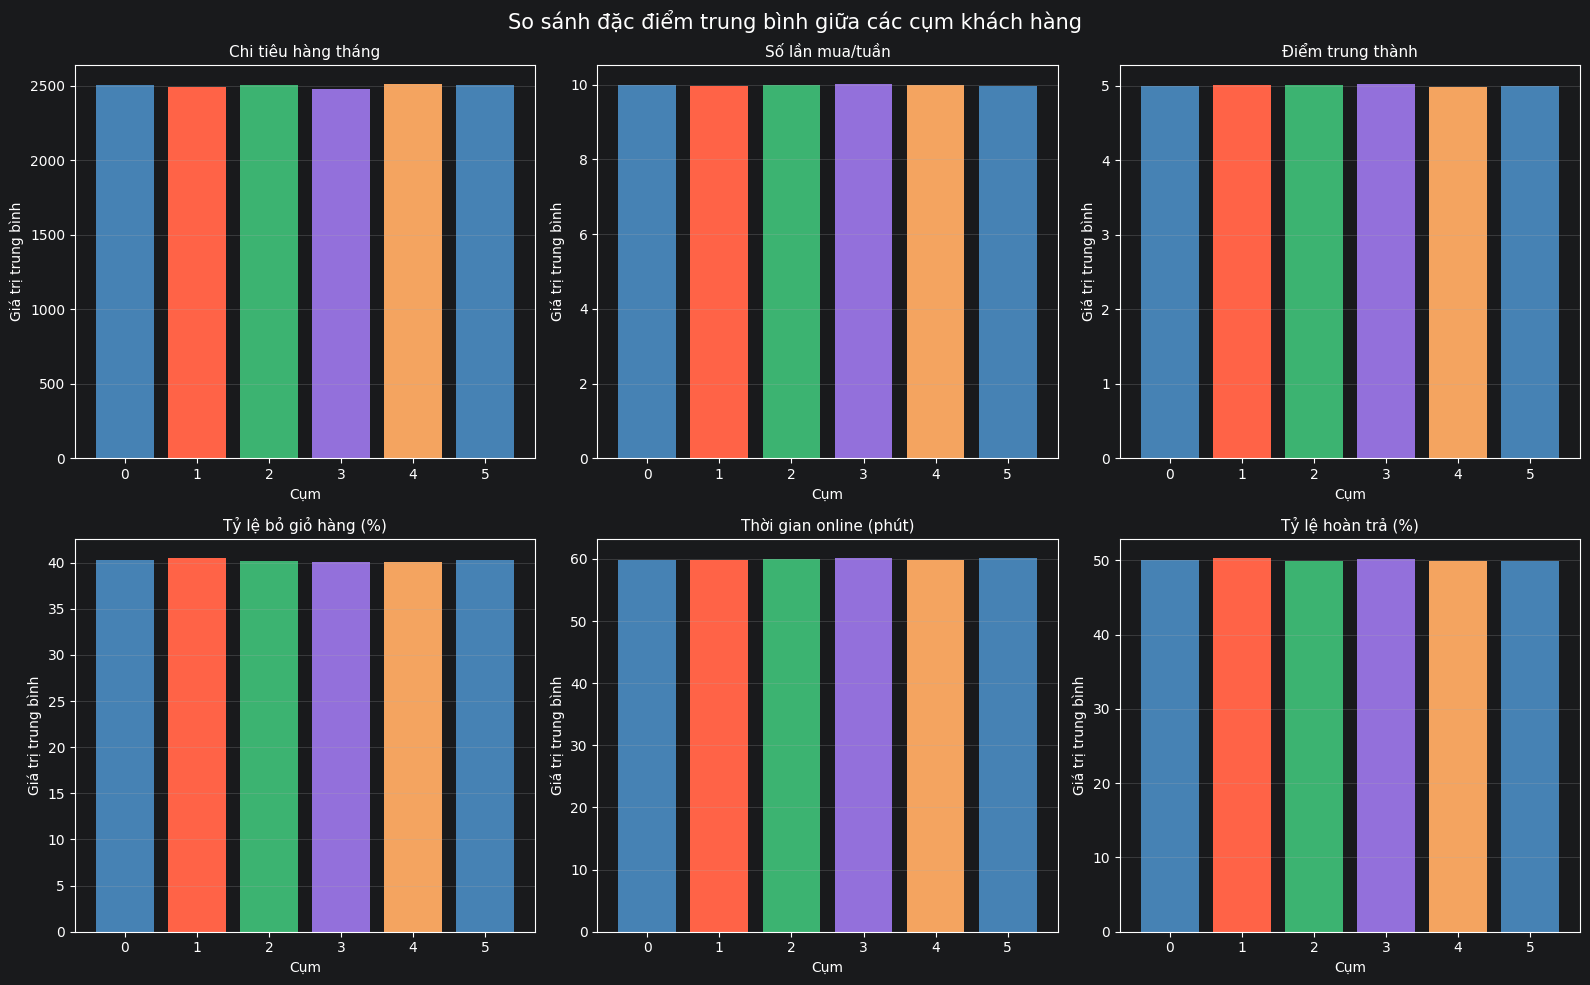

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("So sánh đặc điểm trung bình giữa các cụm khách hàng", fontsize=15)

metrics = [
    ("TB_Chi_Tieu", "Chi tiêu hàng tháng"),
    ("TB_Mua_Hang_Tuan", "Số lần mua/tuần"),
    ("TB_Diem_Trung_Thanh", "Điểm trung thành"),
    ("TB_Bo_Gio_Hang", "Tỷ lệ bỏ giỏ hàng (%)"),
    ("TB_Thoi_Gian_Online", "Thời gian online (phút)"),
    ("TB_Ty_Le_Hoan_Tra", "Tỷ lệ hoàn trả (%)"),
]

colors = ["steelblue", "tomato", "mediumseagreen", "mediumpurple", "sandybrown"]

for idx, (col, title) in enumerate(metrics):
    ax = axes[idx // 3][idx % 3]
    ax.bar(
        profile_pd["prediction"].astype(str),
        profile_pd[col],
        color=colors[:len(profile_pd)]
    )
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Cụm")
    ax.set_ylabel("Giá trị trung bình")
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

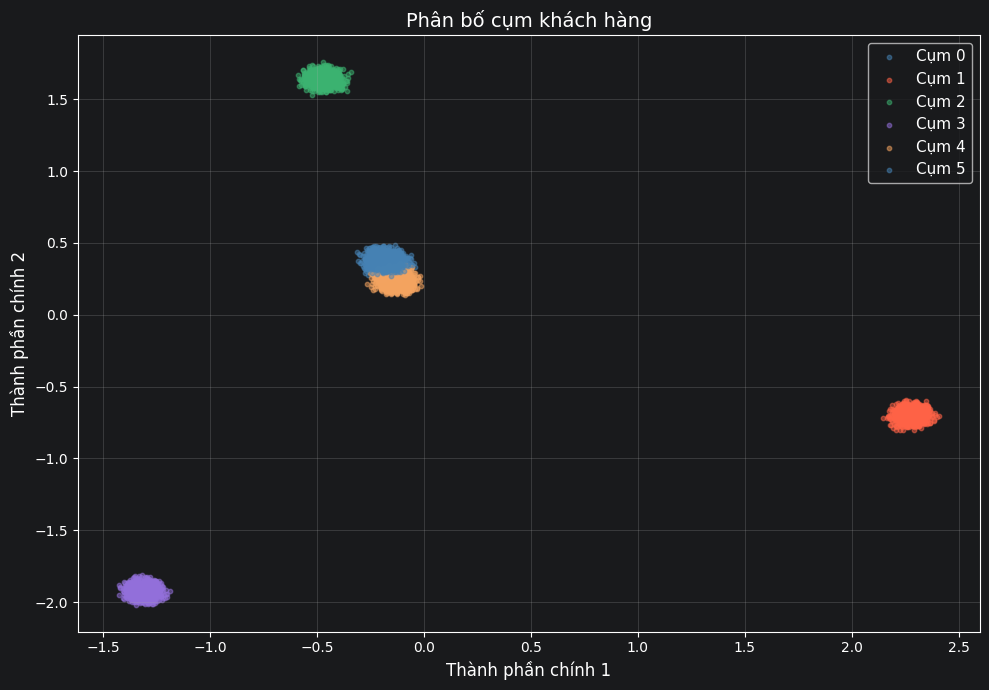

In [9]:
from pyspark.ml.feature import PCA
import numpy as np

pca = PCA(k=2, inputCol="features", outputCol="pca_features")
pca_model = pca.fit(predictions)
df_pca = pca_model.transform(predictions)

pca_pd = df_pca.select("pca_features", "prediction").limit(5000).toPandas()
pca_pd["PC1"] = pca_pd["pca_features"].apply(lambda x: float(x[0]))
pca_pd["PC2"] = pca_pd["pca_features"].apply(lambda x: float(x[1]))

# Vẽ Scatter Plot
plt.figure(figsize=(10, 7))
colors = ["steelblue", "tomato", "mediumseagreen", "mediumpurple", "sandybrown"]

for cluster_id in sorted(pca_pd["prediction"].unique()):
    subset = pca_pd[pca_pd["prediction"] == cluster_id]
    plt.scatter(
        subset["PC1"], subset["PC2"],
        label=f"Cụm {cluster_id}",
        alpha=0.5, s=10,
        color=colors[cluster_id % len(colors)]
    )

plt.title("Phân bố cụm khách hàng", fontsize=14)
plt.xlabel("Thành phần chính 1", fontsize=12)
plt.ylabel("Thành phần chính 2", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()